In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [5]:
dataset1 = pd.read_csv('/content/drive/MyDrive/Deep learning/Exp 1 - Sheet1.csv')
X = dataset1[['Input']].values
y = dataset1[['Output']].values
print(X)
print(y)
dataset1.head()

[[ 8]
 [ 6]
 [22]
 [34]
 [35]
 [64]
 [36]
 [24]
 [15]
 [12]
 [ 6]
 [44]
 [75]
 [98]]
[[ 35]
 [ 46]
 [ 27]
 [ 98]
 [543]
 [ 62]
 [ 87]
 [200]
 [358]
 [623]
 [420]
 [231]
 [185]
 [125]]


,Input,Output
0,8,35
1,6,46
2,22,27
3,34,98
4,35,543


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [7]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [9]:
# Name:
# Register Number:
class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()
        self.fc1=nn.Linear(1,8)
        self.fc2=nn.Linear(8,10)
        self.fc3=nn.Linear(10,1)
        self.relu=nn.ReLU()
        self.history = {'loss': []}
  def forward(self,x):
    x=self.relu(self.fc1(x))
    x=self.relu(self.fc2(x))
    x=self.fc3(x)
    return x






In [11]:
# Initialize the Model, Loss Function, and Optimizer
# Write your code here
lig=NeuralNet()
criterion = nn.MSELoss()
optimizer = optim.RMSprop(lig. parameters(), lr=0.001)

In [13]:
# Name:
# Register Number:
def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
    # Write your code here
    for epoch in range(epochs):
      optimizer.zero_grad()
      loss= criterion (ai_brain(X_train),y_train)
      loss.backward()
      optimizer.step()
      lig.history['loss'].append(loss.item())
      if epoch % 200 == 0:
        print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')


In [16]:
train_model(lig, X_train_tensor, y_train_tensor, criterion, optimizer)


Epoch [0/2000], Loss: 26745.195312
Epoch [200/2000], Loss: 25571.005859
Epoch [400/2000], Loss: 24536.578125
Epoch [600/2000], Loss: 23919.439453
Epoch [800/2000], Loss: 23784.162109
Epoch [1000/2000], Loss: 23781.539062
Epoch [1200/2000], Loss: 23780.587891
Epoch [1400/2000], Loss: 23779.376953
Epoch [1600/2000], Loss: 23777.972656
Epoch [1800/2000], Loss: 23776.000000


In [20]:
with torch.no_grad():
    test_loss = criterion(lig(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')


Test Loss: 57990.136719


In [21]:
loss_df = pd.DataFrame(lig.history)

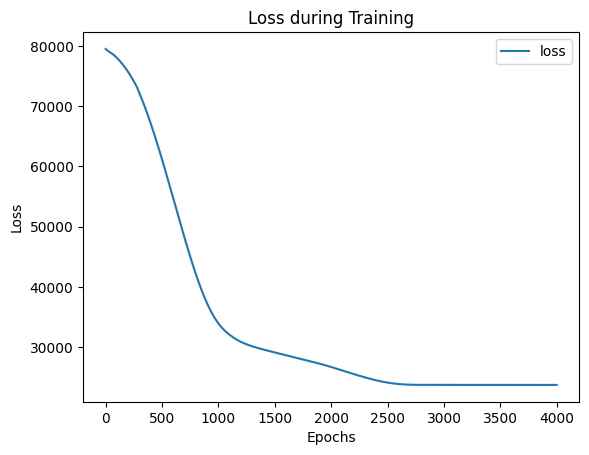

In [22]:
import matplotlib.pyplot as plt
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [23]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = lig(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 321.2774963378906
